# Example-27: Frequency loop

In [1]:
# In this example the main frequency is estimated using different methods
# In all cases window is used and no data filtering is performed (anomaly detection or noise filtering)
# Full signal length is 1024 turns

In [2]:
# Test cases:

# 1. Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
#    Estimate frequency as mean over signals and spread as standard deviation
#    Estimate frequency with OLS fit and spread as OLS standard error

# 2. Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
#    Estimate noise for each signal using optimal SVD and use it in WLS
#    Note, SNR can be used as weights

# 3. Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
#    Estimate standard error for each signal using OLS or WLS (use noise for weighting)
#    Perform WLS fit for the main frequency and its spread

# 4. Estimate the main frequency for sampled signals using 'parabola' interpolation of refined amplitude spectrum
#    Estimate spread for each signal using standard deviation in sample frequencies
#    Perform WLS fit for the main frequency and its spread

# 5. Estimate the main frequency for sampled signals using 'parabola' interpolation of refined amplitude spectrum
#    Estimate noise for each sample, WLS fit to estimate sample spread
#    WLS fit samples to estimate the signal frequency and its spread
#    WLS fit signals to estimate the main frequency and its spread

In [3]:
# Import

import epics
import numpy
import pandas
import torch
import nufft

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

from statsmodels.api import OLS, WLS

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [4]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [5]:
# Reference case

# Set parameters

length = 1024

# Set window

w = Window(length, 'cosine_window', 5.0, dtype=dtype, device=device)

# Load TbT

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Remove mean and apply window

d.window_remove_mean()
d.window_apply()

# Compute reference frequency

f = Frequency(d)
f('parabola')
f_ref, s_ref = f.frequency.mean().cpu().item(), f.frequency.std().cpu().item()

# Reset work

d.reset()

# Print results

print(f'{f_ref:<16.9}')
print(f'{s_ref:<16.9}')

0.463116901     
2.20863159e-16  


In [6]:
# Set data with noise

# Generate noise sigma for each signal

std = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))

# Set test data

d.reset()
d.add_noise(std)
data = d.work
print(data.shape)

# Set spike

data[1, 128] += 0.5
data[1, 256] -= 0.5

torch.Size([54, 1024])


In [7]:
# Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
# Estimate frequency as mean over signal and spread as standard deviation
# Estimate frequency with OLS fit and spread as OLS standard error

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Estimate frequency

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# Estimate the main frequency and its spread using mean and standard deviation

f_out = f.frequency.mean().cpu().item()
s_out = f.frequency.std().cpu().item()
f_1, s_1 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# Estimate the main frequency and its spread using OLS fit

x = numpy.ones((54, 1))
y = f.frequency.cpu().numpy()
out = OLS(y, x).fit()
f_out = out.params.item()
s_out = out.bse.item()
f_2, s_2 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

err: 3.11817058e-06  , std: 2.22709125e-05  
err: 3.11817058e-06  , std: 3.03068731e-06  


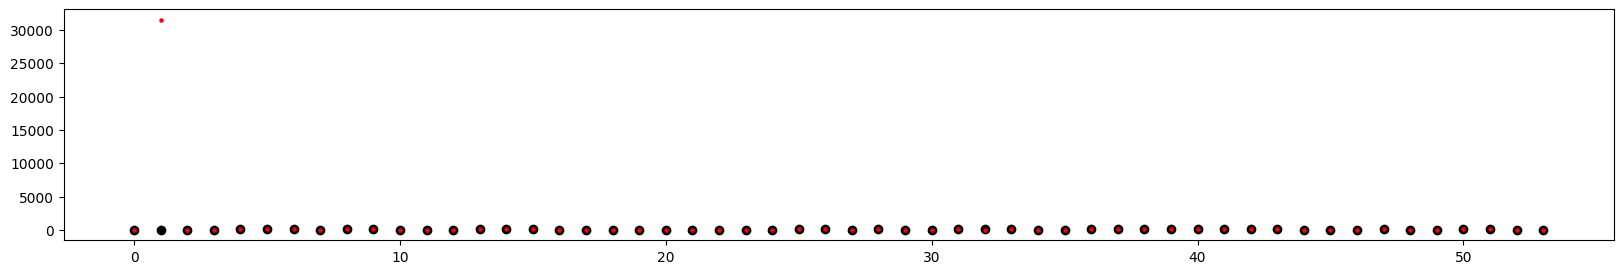

err: 2.26934403e-08  , std: 1.27550207e-07  


In [8]:
# Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
# Estimate noise for each signal using optimal SVD and use it in WLS fit as weight

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Estimate frequency

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# Estimate noise

l = Filter(t)
_, s = l.estimate_noise(limit=32)

# Plot estimated noise and true noise

plt.figure(figsize=(20, 3))
plt.scatter(range(54), std.cpu()*1.0E+6, color='black')
plt.scatter(range(54), s.cpu()*1.0E+6, color='red', s=5)
plt.show()

# Estimate the main frequency and its spread using WLS fit

x = numpy.ones((54, 1))
y = f.frequency.cpu().numpy()
w = (1/s**2).cpu().numpy()
out = WLS(y, x, w).fit()
f_out = out.params.item()
s_out = out.bse.item()
f_3, s_3 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

In [9]:
# Use weighted mean and variance estimation

# Use estimated noise for weighting

weight = 1/s**2
print(f'err: {abs(weighted_mean(f.frequency, weight=weight).cpu().item() - f_ref):<16.9}, std: {weighted_variance(f.frequency, weight=weight).sqrt().cpu().item():<16.9}')

# Use SNR for weighting

weight = 1/s**2*torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2
print(f'err: {abs(weighted_mean(f.frequency, weight=weight).cpu().item() - f_ref):<16.9}, std: {weighted_variance(f.frequency, weight=weight).sqrt().cpu().item():<16.9}')

err: 2.26934407e-08  , std: 9.44444087e-07  
err: 1.85200702e-08  , std: 7.12967418e-07  


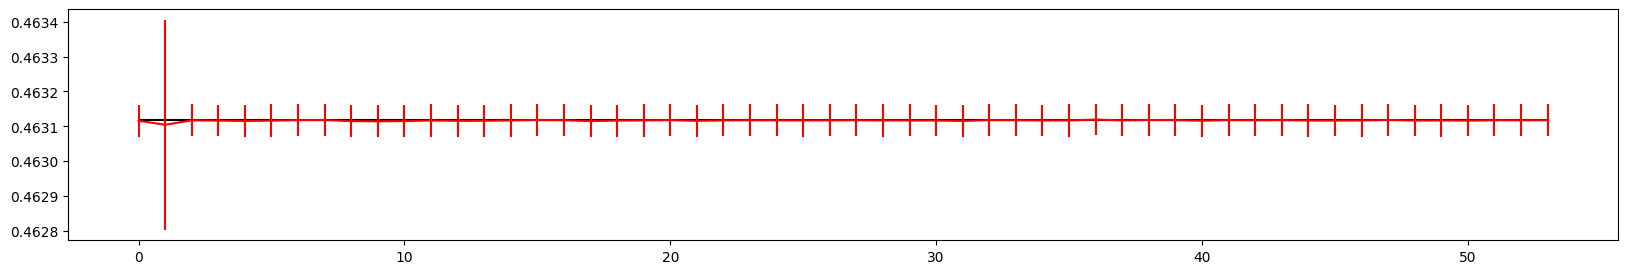

err: 2.42633675e-08  , std: 1.34606412e-07  


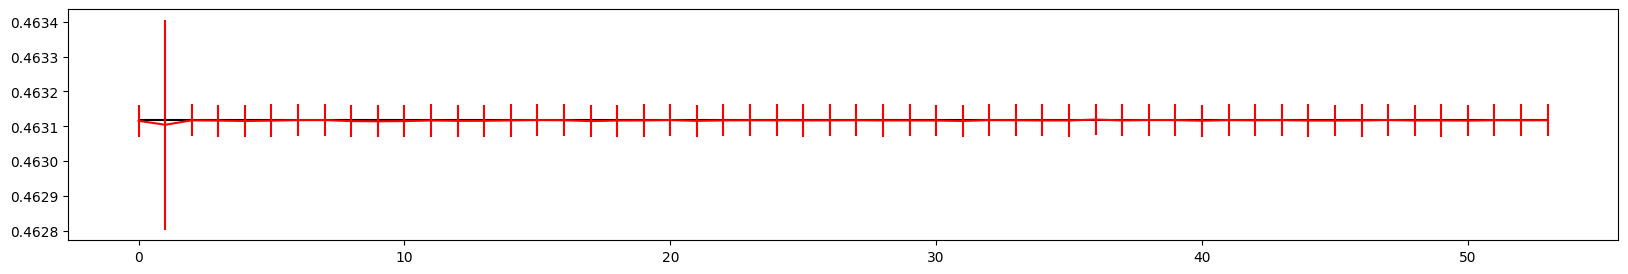

err: 2.41518733e-08  , std: 1.34587231e-07  


In [10]:
# Estimate the main frequency for each signal using 'parabola' interpolation of refined amplitude spectrum
# Estimate standard error for each signal using OLS/WLS
# Perform WLS fit for the main frequency and its spread

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Estimate frequency

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# Estimate noise

l = Filter(t)
_, s = l.estimate_noise(limit=32)

# OLS

f_out, s_out = f.compute_fitted_frequency(mode='ols').T
plt.figure(figsize=(20, 3))
plt.hlines(f_ref, 0, 53, color='black')
plt.errorbar(range(54), f_out.cpu().numpy(), yerr=s_out.cpu().numpy(), color='red')
plt.show()
x = numpy.ones((54, 1))
y = f_out.cpu().numpy()
w = (1/s_out**2).cpu().numpy()
out = WLS(y, x, w).fit()
f_out = out.params.item()
s_out = out.bse.item()
f_4, s_4 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

# WLS

f_out, s_out = f.compute_fitted_frequency(mode='wls', std=s).T
plt.figure(figsize=(20, 3))
plt.hlines(f_ref, 0, 53, color='black')
plt.errorbar(range(54), f_out.cpu().numpy(), yerr=s_out.cpu().numpy(), color='red')
plt.show()
x = numpy.ones((54, 1))
y = f_out.cpu().numpy()
w = (1/s_out**2).cpu().numpy()
out = WLS(y, x, w).fit()
f_out = out.params.item()
s_out = out.bse.item()
f_5, s_5 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

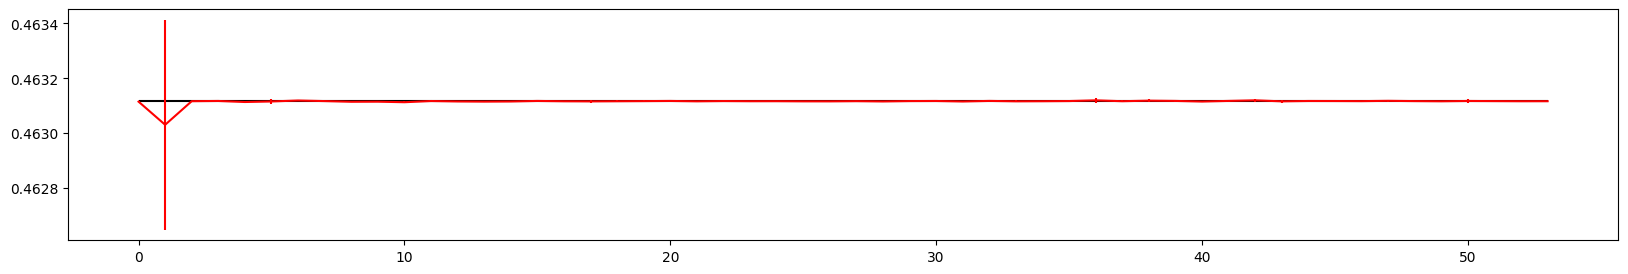

err: 7.61215863e-09  , std: 9.7990326e-08   


In [11]:
# Estimate the main frequency for sampled signals using 'parabola' interpolation of refined amplitude spectrum
# Estimate spread for each signal using standard deviation in sample frequencies
# Perform WLS fit for the main frequency and its spread

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Estimate frequency

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# Estimated frequency for sampled data

out = f.compute_shifted_frequency(512, 8)
f_out = out.mean(1)
s_out = out.std(1)
plt.figure(figsize=(20, 3))
plt.hlines(f_ref, 0, 53, color='black')
plt.errorbar(range(54), f_out.cpu().numpy(), yerr=s_out.cpu().numpy(), color='red')
plt.show()

# WLS fit

x = numpy.ones((54, 1))
y = f_out.cpu().numpy()
w = (1/s_out**2).cpu().numpy()
out = WLS(y, x, w).fit()
f_out = out.params.item()
s_out = out.bse.item()
f_6, s_6 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

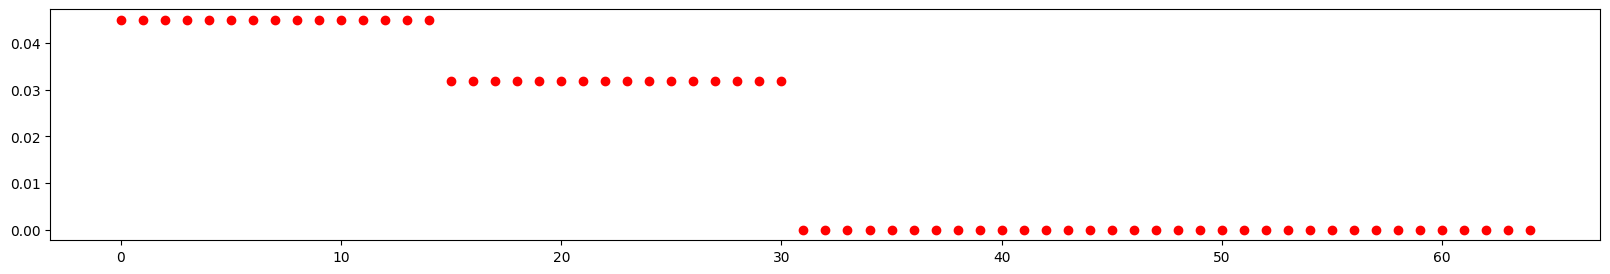

err: 2.23303732e-08  , std: 1.01739356e-07  


In [12]:
# Estimate the main frequency for sampled signals using 'parabola' interpolation of refined amplitude spectrum
# Estimate noise for each sample, WLS fit to estimate sample spread
# WLS fit samples to estimate signal frequency and its spread
# WLS fit signals to estimate the main frequency and its spread

# Set data

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, data)

# Sample data

w = Window(512, 'cosine_window', 1.0, dtype=dtype, device=device)
t = Data.from_data(w, torch.cat([t.make_matrix(512, 8, t.work[i]) for i in range(54)]))
n = t.size//54

# Estimate noise for all samples

l = Filter(t)
_, s = l.estimate_noise(limit=32)

# Plot noise estimation for signal with spike

plt.figure(figsize=(20, 3))
plt.scatter(range(n), s.cpu().reshape(54, -1)[1], color='red')
plt.show()

# Estimate frequency for each sample

t.window_remove_mean()
t.window_apply()
f = Frequency(t)
f('parabola')
t.reset()

# WLS fit samples

f_out = f.frequency.reshape(54, -1)
s_out = s.reshape(54, -1)
table = []
for i in range(54):
    x = numpy.ones((n, 1))
    y = f_out[i].cpu().numpy()
    w = (1/s_out[i]**2).cpu().numpy()
    out = WLS(y, x, w).fit()
    table.append([out.params.item(), out.bse.item()])
    
f_out, s_out = numpy.array(table).T

# WLS fit signals

x = numpy.ones((54, 1))
y = f_out
w = (1/s_out**2)
out = WLS(y, x, w).fit()
f_out = out.params.item()
s_out = out.bse.item()
f_7, s_7 = f_out, s_out
print(f'err: {abs(f_out - f_ref):<16.9}, std: {s_out:<16.9}')

In [13]:
# Compare results

# 1 -- mean & std over signals
# 2 -- OLS fit over signals
# 3 -- WLS fit over signals using estimated noise as weight
# 4 -- OLS fit for signal, WLS fit over signals
# 5 -- WLS fit for signal, WLS fit over signals
# 6 -- mean & std over samples, WLS fit over signals
# 7 -- WLS fit over samples, WLS fit over signals

print(f'case: 1, err: {abs(f_1 - f_ref):<16.9}, std: {s_1:<16.9}')
print(f'case: 2, err: {abs(f_2 - f_ref):<16.9}, std: {s_2:<16.9}')
print(f'case: 3, err: {abs(f_3 - f_ref):<16.9}, std: {s_3:<16.9}')
print(f'case: 4, err: {abs(f_4 - f_ref):<16.9}, std: {s_4:<16.9}')
print(f'case: 5, err: {abs(f_5 - f_ref):<16.9}, std: {s_5:<16.9}')
print(f'case: 6, err: {abs(f_6 - f_ref):<16.9}, std: {s_6:<16.9}')
print(f'case: 7, err: {abs(f_7 - f_ref):<16.9}, std: {s_7:<16.9}')

case: 1, err: 3.11817058e-06  , std: 2.22709125e-05  
case: 2, err: 3.11817058e-06  , std: 3.03068731e-06  
case: 3, err: 2.26934403e-08  , std: 1.27550207e-07  
case: 4, err: 2.42633675e-08  , std: 1.34606412e-07  
case: 5, err: 2.41518733e-08  , std: 1.34587231e-07  
case: 6, err: 7.61215863e-09  , std: 9.7990326e-08   
case: 7, err: 2.23303732e-08  , std: 1.01739356e-07  


In [14]:
# Weighted mean & variance

# Do over samples
# Gives more realistic error estimation

amplitude = torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2

f_out = f.frequency
s_out = s

center = weighted_mean(f_out, weight=1/s_out**2)
spread = weighted_variance(f_out, weight=1/s_out**2, center=center).sqrt()
print(f'err: {abs(center.item() - f_ref):<16.9}, std: {spread.item():<16.9}')

center = weighted_mean(f_out, weight=amplitude**2/s_out**2)
spread = weighted_variance(f_out, weight=amplitude**2/s_out**2, center=center).sqrt()
print(f'err: {abs(center.item() - f_ref):<16.9}, std: {spread.item():<16.9}')

err: 1.90802201e-08  , std: 2.61398992e-06  
err: 2.91557073e-09  , std: 1.16603597e-06  


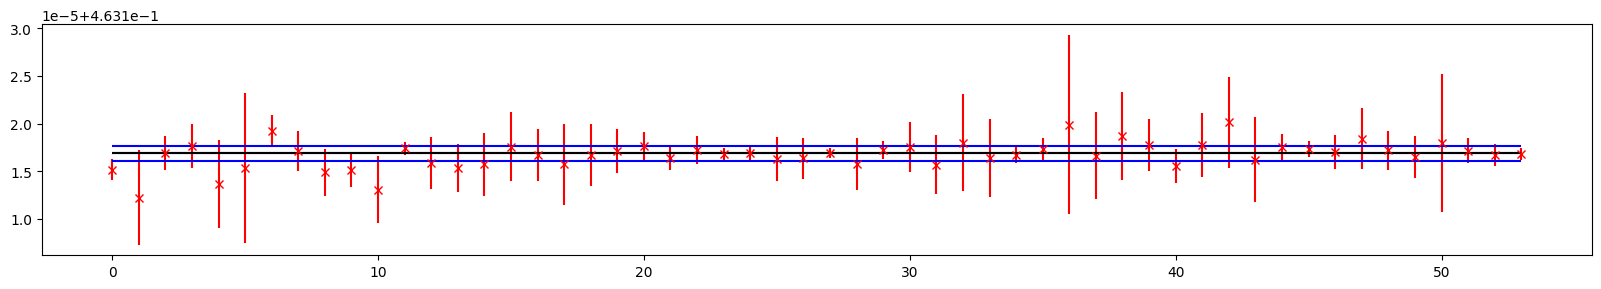

err: 1.96414207e-08  , std: 7.55664154e-07  


In [15]:
# Weighted mean & variance

# Do over samples for each signal, do over signals
# Gives more realistic error estimation

amplitude = torch.stack([spectrum[index] for index, spectrum in zip(f.ffrft_bin.to(torch.int64), f.ffrft_spectrum)])**2

f_out = f.frequency.reshape(54, -1)
s_out = s.reshape(54, -1)

center = weighted_mean(f_out, weight=amplitude.reshape(54, -1)/s_out**2)
spread = weighted_variance(f_out, weight=amplitude.reshape(54, -1)/s_out**2, center=center).sqrt()
plt.figure(figsize=(20, 3))
plt.errorbar(range(54), center.cpu().numpy(), yerr=spread.cpu().numpy(), fmt=' ', color='red', marker='x')
center, spread = weighted_mean(center, weight=1/spread**2), weighted_variance(center, weight=1/spread**2).sqrt()
plt.hlines(center.cpu().item() - spread.cpu().item(), 0, 53, color='blue')
plt.hlines(center.cpu().item(), 0, 53, color='blue')
plt.hlines(center.cpu().item() + spread.cpu().item(), 0, 53, color='blue')
plt.hlines(f_ref, 0, 53, color='black')
plt.show()

print(f'err: {abs(center.item() - f_ref):<16.9}, std: {spread.item():<16.9}')